In [182]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Naina Bhatnagar\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1


In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [184]:
import os
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

In [185]:
df = pd.read_csv(full_path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [187]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df,test_size=0.2, random_state=42)


In [188]:
def transformations(data):
    data["gender"] = data["sex"].map({'female': 0, 'male': 1})
    data.drop("sex", axis=1, inplace=True)
    data["smoker"] = data["smoker"].map({'no': 0, 'yes': 1})
    data = pd.get_dummies(data, columns=['region'])
    return data

In [189]:
train = transformations(train)

In [190]:
corr_mat = train.corr(numeric_only=True)
corr_mat["charges"]

age                 0.281721
bmi                 0.197316
children            0.071885
smoker              0.780063
charges             1.000000
gender              0.056802
region_northeast   -0.000628
region_northwest   -0.033776
region_southeast    0.067491
region_southwest   -0.034994
Name: charges, dtype: float64

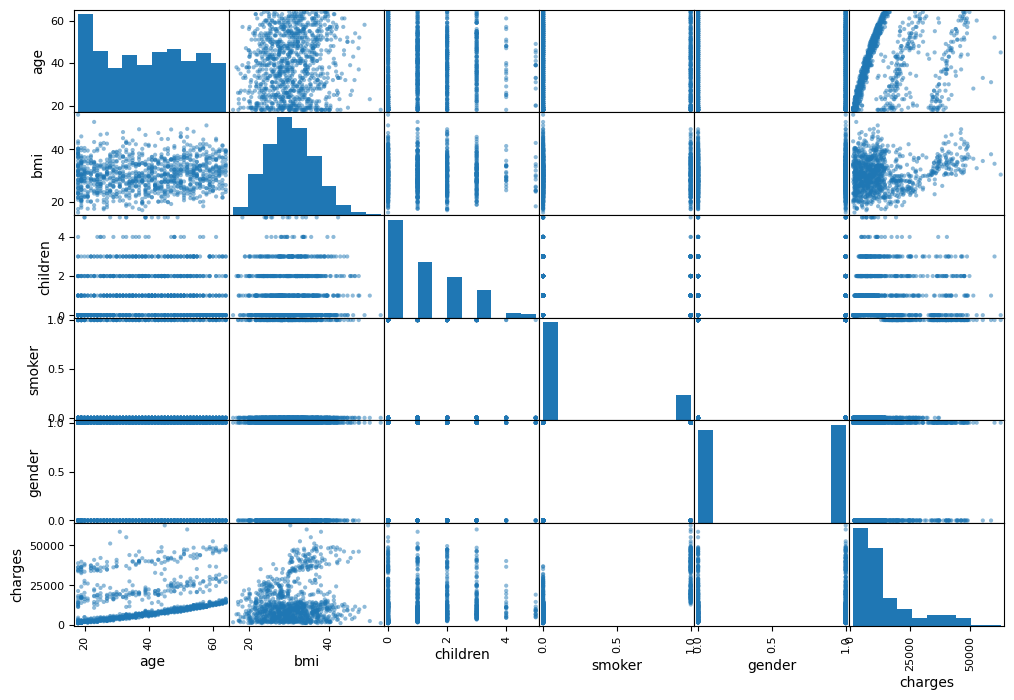

In [191]:
from pandas.plotting import scatter_matrix
attr = ["age","bmi","children","smoker","gender","charges"]
scatter_matrix(train[attr], figsize=(12,8))
plt.show()

In [192]:
test = transformations(test)

In [193]:
y = train["charges"]
X = train.drop("charges", axis=1)
test_y = test["charges"]
test_X = test.drop("charges", axis=1)

In [194]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [195]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=10)
rmse_scores = np.sqrt(-scores)
print("Mean Score:", rmse_scores.mean())
print("Standard Deviation:", rmse_scores.std())

Mean Score: 4952.334470036267
Standard Deviation: 488.8964360050815


In [198]:
model.fit(X,y)
test_pred = model.predict(test_X)

In [199]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
mae = mean_absolute_error(test_y,test_pred)
mse = mean_squared_error(test_y,test_pred)
rmse = np.sqrt(mse)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 2555.51
RMSE: 4591.57
